In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import random

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim

import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, SubsetRandomSampler

from sklearn.model_selection import train_test_split

import dlib
import cv2
import face_recognition
import sys

from PIL import UnidentifiedImageError
from PIL import Image

from insightface import app
from tqdm.autonotebook import tqdm as tqdm

from facenet_pytorch import MTCNN, InceptionResnetV1

/opt/anaconda3/envs/myenv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


This document features a face recognition model using a combination of face detection (using MTCNN) and face classification. It utilizes the pre-trained InceptionResnetV1 (a version of FaceNet) for feature extraction and integrates a custom classifier to identify specific individuals based on facial features.

In [3]:
# define the number of classes (people) in pins dataset
num_classes = 106

# Load a pre-trained FaceNet model (InceptionResnetV1) which will be used to extract face embeddings
model = InceptionResnetV1(pretrained='vggface2').eval()

# Define a classifier for face classification where  512 classes is the output of the model InceptionResnetV1
# (last_linear): Linear(in_features=1792, out_features=512, bias=False)
classifier = nn.Sequential(
    # nn.Linear(512, 256),
    nn.Linear(512, num_classes)
)

# Set the device to GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move the model and the classifier to the device (CPU or GPU)
model = model.to(device)
classifier = classifier.to(device)


In [5]:
# load the model weights from the previous training
weights_path = 'facenetmodel_weights.pth'
state_dict = torch.load(weights_path)
model.load_state_dict(state_dict, strict=False)

_IncompatibleKeys(missing_keys=['logits.weight', 'logits.bias'], unexpected_keys=[])

# Model Description:
The TripleLossDataset is constructed using detected with MTCNN faces to filter out photos with without detectable faces.

For each image in the dataset, a ‘Positive’ (i.e., another image of the same person) and a correcsponding ‘Negative’ (an image of a different person) are selected for the training triplet.

The dataset is split into 3 groups: 
* training dataset (train_loader), which makes up 70% of the total dataset length
* test and validation datasets , each making up 15% of the data

A pre-trained InceptionResnetV1 model is used for feature extraction. A classification is applied for face recognition based on the exctracted features.

In [43]:
# Initialise a face detector. keep_all is used to return only 1 detected face
mtcnn = MTCNN(keep_all=False)  

# A custom dataset class for training with triplet loss
class TripleLossDataset(Dataset):
    def __init__(self, img_dir, transforms=None):
        self.img_dir = img_dir
        self.transforms = transforms
        self.persons = sorted(os.listdir(img_dir))

        # define a mapping of a person's name with a numerical label
        self.label_map = {person.lower().split('pins_')[1]: idx for idx, person in enumerate(self.persons, start=0) if person!='.DS_Store'}

         # Initialize lists to store valid face image paths and labels
        self.valid_faces = []
        self.valid_labels = []
        self.label_to_img = {}

        # iterate over each person's directory and collect images
        for person_name in self.persons:
            if person_name != '.DS_Store':
                person_dir = os.path.join(img_dir, person_name)
                # check if the path is valid
                if os.path.isdir(person_dir):
                    self.person_images_path_lst = []
                    person_label = self.label_map[person_name.lower().split('pins_')[1]]
                    # iterate over images in the person's directory
                    for img_name in os.listdir(person_dir):
                        img_path = os.path.join(person_dir, img_name)
                        if os.path.isfile(img_path):
                            img = Image.open(img_path).convert('RGB')
                            face = mtcnn(img)
                            # add the detectable faces path to the lists
                            if face is not None:
                                self.person_images_path_lst.extend([img_path])
                                self.valid_faces.append(img_path)
                                self.label_to_img[person_label] = self.person_images_path_lst
                    # Store the images and their corresponding labels
                    if img_path:
                        self.valid_labels.extend([person_label] * len(self.person_images_path_lst))

    def __getitem__(self, idx):
        '''
        Create a triplet with the anchor image, a ‘Positive’ (i.e., another image of the same person) 
        and a correcsponding ‘Negative’ (an image of a different person) images
        '''
        anchor_face_path = self.valid_faces[idx]
        anchor_label = self.valid_labels[idx]
        # select a random image of the same person
        positive_image_path = random.choice(self.label_to_img[anchor_label])

        # make sure the positive and the anchor image are not the same
        while positive_image_path == anchor_face_path:
            positive_image_path = random.choice(self.label_to_img[anchor_label])

        # select a random image of a different person
        negative_label = random.choice([neg for neg in self.label_to_img.keys()])
        negative_image_path = random.choice(self.label_to_img[negative_label])

        # open and convert the images to RGB
        anchor_img = Image.open(anchor_face_path).convert('RGB')
        positive_img = Image.open(positive_image_path).convert('RGB')
        negative_img = Image.open(negative_image_path).convert('RGB')

        # apply the transformations (resizing, to tensor, etc)
        if self.transforms:
            anchor_img = self.transforms(anchor_img)
            positive_img = self.transforms(positive_img)
            negative_img = self.transforms(negative_img)
            
        return anchor_img, positive_img, negative_img, anchor_label

    def __len__(self):
        return len(self.valid_faces)

In [44]:
# images directory
img_dir = '105_classes_pins_dataset'
dataset = TripleLossDataset(img_dir)
data_loader = DataLoader(dataset, batch_size=1, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))

[]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [46]:
# split the dataset into 3 categories: training, testing and validation
dataset_for_splitting = torch.arange(len(dataset))

train_indices, temp_indices = train_test_split(dataset_for_splitting, test_size=0.3, random_state=42)

val_indices, test_indices = train_test_split(temp_indices, test_size=0.3, random_state=42)

train_sampler = SubsetRandomSampler(train_indices)
val__sampler = SubsetRandomSampler(val_indices)
test_sampler = SubsetRandomSampler(test_indices)

triplet_train_loader = DataLoader(dataset, batch_size=1, sampler=train_sampler, collate_fn=lambda x: tuple(zip(*x)))
triplet_val_loader = DataLoader(dataset, batch_size=1, sampler=val__sampler, collate_fn=lambda x: tuple(zip(*x)))
triplet_test_loader = DataLoader(dataset, batch_size=1, sampler=test_sampler, collate_fn=lambda x: tuple(zip(*x)))

In [63]:
def triplet_loss(anchor, positive_image, negative_image, margin=1):
  #   Efficient computation of Euclidean distance matrix
  # Args:
  #   x: Input tensor of shape (batch_size, embedding_dim)
    
  # Returns:
  #   Distance matrix of shape (batch_size, batch_size)
    # distance = √Σ(a-b)**2
    anchor_pos_distance = torch.norm(anchor - positive_image, dim=1)
    anchor_neg_distance = torch.norm(anchor - negative_image, dim=1)
    triplet_loss = torch.max(torch.zeros_like(anchor_pos_distance), anchor_pos_distance - anchor_neg_distance + margin)
    return triplet_loss.mean()

In [65]:
# define the lists to store training and testing loss and accuracies, will be further used for the visualisation
train_losses_facenet_triplet = []
train_accuracies_facenet_triplet  = []
test_losses_facenet_triplet = []
test_accuracies_facenet_triplet = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# define the classifier loss function (Cross-Entropy Loss is standard for multi-class classification)
classifier_criterion = nn.CrossEntropyLoss()

# initialize the optimizer for the classifier
optimizer = torch.optim.Adam(classifier.parameters(), lr=0.001)

In [66]:
# apply the transformations: resizing, tensor and normalisation
transform = transforms.Compose([
    transforms.Resize((250, 250)),  
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [67]:
def train_triplet_loss(model, classifier, triplet_train_loader, epoch, device='cpu', criterion=triplet_loss, classifier_criterion=nn.CrossEntropyLoss, optimizer=optimizer):
    '''
    Function to train a classifier using triplet loss and cross-entropy loss
    '''
    # set the FaceNet model is in evaluation mode for feature extraction
    model.eval()
    # set the classifier to train mode for the face classification
    classifier.train()
    
    total_triplet_loss = 0
    correct = 0
    total_samples = 0

    # iterate over the train_loader
    for batch_idx, (anchor_imges, positive_imges, negative_imges, anchor_label) in enumerate(triplet_train_loader):
        anchor = torch.stack([transform(anchor_img).to(device) for anchor_img in anchor_imges]).to(device)
        positive_img = torch.stack([transform(positive_img).to(device) for positive_img in positive_imges]).to(device)
        negative_img = torch.stack([transform(negative_img).to(device) for negative_img in negative_imges]).to(device)
        anchor_label = torch.tensor(anchor_label).to(device)
        
        # extract face embeddings using the FaceNet model
        anchor_emb = model(anchor)
        positive_img_emb = model(positive_img)
        negative_img_emb = model(negative_img)

        # compute the triplet loss: to ensure that the distance between the anchor and the positive is smaller  
        # than the distance between the anchor and the negative
        triplet_loss = criterion(anchor_emb, positive_img_emb, negative_img_emb)

        # compute the classifier loss: 
        outputs = classifier(anchor_emb)
        classifier_loss = classifier_criterion(outputs, anchor_label)

        # calculate the total loss of the batch
        loss = triplet_loss + classifier_loss
        total_triplet_loss += loss.item()
        # calculate the number of total samples (to calculate the accuracy)
        total_samples += anchor_label.size(0)

        # backpropagation
        optimizer.zero_grad() # clear previous gradients
        loss.backward() #compute gradients
        optimizer.step() # update model parameters

        # predict classes
        probability = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(probability, 1)

        # calculate the number of correctly predicted classes
        correct += (predicted == anchor_label).sum().item()
        
        # Print training progress every 1000 batches
        if batch_idx % 1000 == 0:
            print(f'Epoch: {epoch} [{batch_idx * len(anchor)}/{len(triplet_train_loader.dataset)}], loss: {loss.item()}')

    # calculate average loss and accuracy for the epoch 
    avg_loss = total_triplet_loss / len(triplet_train_loader)
    accuracy = 100. * correct / total_samples
    
    # append the average loss and accuracy to the lists for visualization
    train_losses_facenet_triplet.append(avg_loss)
    train_accuracies_facenet_triplet.append(accuracy)
    
    print(f'Epoch {epoch}, Train Avg Loss: {avg_loss}, Train Accuracy: {accuracy}%')

In [68]:
def test_triplet_loss(model, classifier, triplet_test_loader, device='cpu', epoch=1, classifier_criterion=nn.CrossEntropyLoss, criterion=triplet_loss):
    '''
    Function to test a classifier using triplet loss and cross-entropy loss with further visualisation
    '''

    # set the FaceNet model is in evaluation mode for feature extraction
    model.eval()
    # set the classifier is in evaluation mode for classification
    classifier.eval()
    
    total_triplet_loss = 0
    correct = 0
    total_samples = 0
    
    with torch.no_grad():
        for batch_idx, (anchor_imges, positive_imges, negative_imges, anchor_label) in enumerate(triplet_test_loader):
             # apply transformations and move to device
            anchor = torch.stack([transform(anchor_img).to(device) for anchor_img in anchor_imges]).to(device)
            positive_img = torch.stack([transform(positive_img).to(device) for positive_img in positive_imges]).to(device)
            negative_img = torch.stack([transform(negative_img).to(device) for negative_img in negative_imges]).to(device)
            anchor_label = torch.tensor(anchor_label).to(device)

            # extract face embeddings using the FaceNet model
            anchor_emb = model(anchor)
            positive_img_emb = model(positive_img)
            negative_img_emb = model(negative_img)

            # compute the triplet loss: to ensure that the distance between the anchor and the positive is smaller  
            # than the distance between the anchor and the negative
            triplet_loss = criterion(anchor_emb, positive_img_emb, negative_img_emb)
            
            # compute the classifier loss: 
            outputs = classifier(anchor_emb)
            classifier_loss = classifier_criterion(outputs, anchor_label)
            
            # compute the total loss for the batch
            loss = triplet_loss + classifier_loss
            total_triplet_loss += loss.item()
            # calculate the number of total samples (to calculate the accuracy)
            total_samples += anchor_label.size(0)

            # predict classes
            probability = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(probability, 1)
            
            # calculate the number of correctly predicted classes
            correct += (predicted == anchor_label).sum().item()

    # calculate average loss and accuracy for the epoch 
    avg_loss = total_triplet_loss / len(triplet_test_loader)
    accuracy = 100. * correct / total_samples
    # append the average loss and accuracy to the lists for visualization
    test_losses_facenet_triplet.append(avg_loss)
    test_accuracies_facenet_triplet.append(accuracy)
    
    print(f'Epoch {epoch}, Test Avg Loss: {avg_loss}, Test Accuracy: {accuracy}%')
    
    return avg_loss, accuracy

In [79]:
num_epochs = 5
for epoch in range(num_epochs):
    train_triplet_loss(model, classifier, triplet_train_loader, epoch=epoch, device=device, criterion=triplet_loss, classifier_criterion=classifier_criterion, optimizer=optimizer)
    test_triplet_loss(model, classifier, triplet_test_loader, device=device, epoch=epoch, classifier_criterion=classifier_criterion, criterion=triplet_loss)

Epoch: 0 [0/17485], loss: 0.9723370671272278
Epoch: 0 [1000/17485], loss: 0.5467069149017334
Epoch: 0 [2000/17485], loss: 0.8582335114479065
Epoch: 0 [3000/17485], loss: 1.0670933723449707
Epoch: 0 [4000/17485], loss: 2.902033567428589
Epoch: 0 [5000/17485], loss: 0.3277950584888458
Epoch: 0 [6000/17485], loss: 0.8205973505973816
Epoch: 0 [7000/17485], loss: 0.8116359710693359
Epoch: 0 [8000/17485], loss: 0.5525792837142944
Epoch: 0 [9000/17485], loss: 0.8352311849594116
Epoch: 0 [10000/17485], loss: 0.38947129249572754
Epoch: 0 [11000/17485], loss: 3.308499336242676
Epoch: 0 [12000/17485], loss: 0.7485784292221069
Epoch 0, Train Avg Loss: 1.0416287411145384, Train Accuracy: 92.63011683961108%
1574
Epoch 0, Test Avg Loss: 1.1384012554825451, Test Accuracy: 89.70775095298602%
Epoch: 1 [0/17485], loss: 2.275763988494873
Epoch: 1 [1000/17485], loss: 3.412353038787842
Epoch: 1 [2000/17485], loss: 0.7094210982322693
Epoch: 1 [3000/17485], loss: 0.7910602688789368
Epoch: 1 [4000/17485], loss

In [80]:
def plot_training_history(train_losses, test_losses, train_accuracies, test_accuracies):
    '''
    The function for the visualisation of the training and testing results
    '''
    
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'bo-', label='Training Loss')
    plt.plot(epochs, test_losses, 'ro-', label='Test Loss')
    plt.title('Training and Test Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'bo-', label='Training Accuracy')
    plt.plot(epochs, test_accuracies, 'ro-', label='Test Accuracy')
    plt.title('Training and Test Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

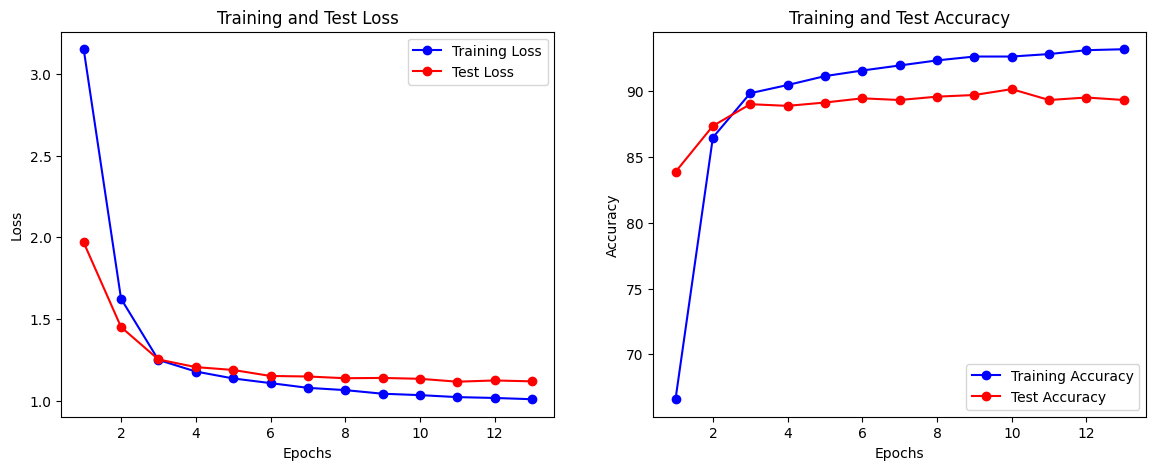

In [81]:
plot_training_history(train_losses_facenet_triplet, test_losses_facenet_triplet, train_accuracies_facenet_triplet, test_accuracies_facenet_triplet)

In [90]:
def test_triplet_loss(model, classifier, triplet_test_loader, device='cpu', epoch=1, classifier_criterion=nn.CrossEntropyLoss, criterion=triplet_loss):
    '''
    Function to validate the classifier performance without further visualistion
    '''

    # set the FaceNet model is in evaluation mode for feature extraction
    model.eval()
    # set the classifier is in evaluation mode for classification
    classifier.eval()
    
    total_triplet_loss = 0
    correct = 0
    total_samples = 0
    
    with torch.no_grad():
        for batch_idx, (anchor_imges, positive_imges, negative_imges, anchor_label) in enumerate(triplet_test_loader):
             # apply transformations and move to device
            anchor = torch.stack([transform(anchor_img).to(device) for anchor_img in anchor_imges]).to(device)
            positive_img = torch.stack([transform(positive_img).to(device) for positive_img in positive_imges]).to(device)
            negative_img = torch.stack([transform(negative_img).to(device) for negative_img in negative_imges]).to(device)
            anchor_label = torch.tensor(anchor_label).to(device)

            # extract face embeddings using the FaceNet model
            anchor_emb = model(anchor)
            positive_img_emb = model(positive_img)
            negative_img_emb = model(negative_img)

            # compute the triplet loss: to ensure that the distance between the anchor and the positive is smaller  
            # than the distance between the anchor and the negative
            triplet_loss = criterion(anchor_emb, positive_img_emb, negative_img_emb)
            
            # compute the classifier loss: 
            outputs = classifier(anchor_emb)
            classifier_loss = classifier_criterion(outputs, anchor_label)
            
            # compute the total loss for the batch
            loss = triplet_loss + classifier_loss
            total_triplet_loss += loss.item()
            # calculate the number of total samples (to calculate the accuracy)
            total_samples += anchor_label.size(0)

            # predict classes
            probability = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(probability, 1)
            
            # calculate the number of correctly predicted classes
            correct += (predicted == anchor_label).sum().item()

    # calculate average loss and accuracy for the epoch 
    avg_loss = total_triplet_loss / len(triplet_test_loader)
    accuracy = 100. * correct / total_samples
    
    print(f'Epoch {epoch}, Test Avg Loss: {avg_loss}, Test Accuracy: {accuracy}%')
    
    return avg_loss, accuracy

In [92]:
validate_accuracy(model, classifier, triplet_val_loader, device='cpu',classifier_criterion=classifier_criterion, criterion=triplet_loss)

(88.31699346405229, 2.668166302377876)

In [105]:
# save the model
torch.save(model.state_dict(), weights_path)